#1 Чтение и обработка данных

In [24]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import roc_auc_score
import numpy as np
import os
import cv2
import pandas as pd

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from dataclasses import dataclass, field

import torchvision.models as models



n_files = len(os.listdir('/content/drive/MyDrive/data/ML9/images'))
print(f" Количество файлов: {n_files}")

train_df = pd.read_csv('/content/drive/MyDrive/data/ML9/Train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/data/ML9/Test.csv')

print(f"\n Train.csv: {train_df.shape}")
print(train_df.head())


 Количество файлов: 8928

 Train.csv: (6249, 2)
            img_IDS             Label
0  ImageID_33HMDMJ3            Temple
1  ImageID_V5POEX4O            Church
2  ImageID_89CCCCW6  Enough/Satisfied
3  ImageID_GNJXOWX5                Me
4  ImageID_7Q9LOP7R              Love


In [10]:
print("\n Распределение классов:")
print(train_df['Label'].value_counts())


train_df_split, valid_df = train_test_split(
    train_df,
    test_size=0.33,
    random_state=42,
    stratify=train_df['Label']
)

print(f"\n Train: {len(train_df_split)} примеров")
print(f" Valid: {len(valid_df)} примеров")




 Распределение классов:
Label
Enough/Satisfied    695
Seat                695
Mosque              695
Temple              694
Church              694
Love                694
Me                  694
You                 694
Friend              694
Name: count, dtype: int64

 Train: 4186 примеров
 Valid: 2063 примеров


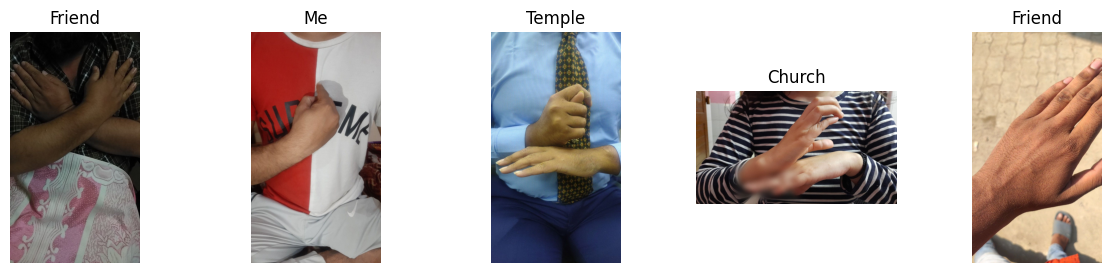

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    row = train_df.sample(1).iloc[0]
    img_path = f"/content/drive/MyDrive/data/ML9/images/{row['img_IDS']}"

    img = Image.open(f"{img_path}.jpg")

    ax.imshow(img)
    ax.set_title(f"{row['Label'][:10]}")
    ax.axis('off')

plt.show()

#2 Свой класс для извлечения изображений и меток

In [11]:
import shutil
import os

src = '/content/drive/MyDrive/data/ML9/images'
dst = '/content/images'

#Копируем изображения в локальную память Colab...
if not os.path.exists(dst):
    shutil.copytree(src, dst)



In [30]:
class GestureDataset(Dataset):
    def __init__(self, df, img_dir, img_size=(224, 224), transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.img_size = img_size

        self.labels_to_idx = {label: idx for idx, label in enumerate(df['Label'].unique())}
        self.idx_to_labels = {idx: label for label, idx in self.labels_to_idx.items()}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['img_IDS']
        label = row['Label']

        for ext in ['jpg', 'jpeg', 'png']:
            img_path = os.path.join(self.img_dir, f"{img_id}.{ext}")
            if os.path.exists(img_path):
                break

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']  # забираем готовый тензор
        else:
            # Фоллбэк, если transform=None
            img = cv2.resize(img, self.img_size, interpolation=cv2.INTER_LINEAR)
            img = torch.from_numpy(img).float().permute(2, 0, 1) / 255.0

        label_idx = self.labels_to_idx[label]
        return img, label_idx

In [31]:
img_dir = '/content/images'

train_dataset = GestureDataset(train_df_split, img_dir, img_size=(128, 128))
valid_dataset = GestureDataset(valid_df, img_dir, img_size=(128, 128))


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f" Train samples: {len(train_dataset)}")
print(f" Valid samples: {len(valid_dataset)}")

images, labels = next(iter(train_loader))
print(f"\n Размер батча: {images.shape}")
print(f" Уникальных классов: {len(train_dataset.labels_to_idx)}")

 Train samples: 4186
 Valid samples: 2063

 Размер батча: torch.Size([64, 3, 128, 128])
 Уникальных классов: 9


#3 Lenet-5

In [32]:
class ModifiedLeNet5(nn.Module):
    def __init__(self, num_classes=9, dropout_rate=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2 = nn.BatchNorm2d(16)
        self.conv3 = nn.Conv2d(16, 32, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(6272, 120)
        self.bn_fc1 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.bn_fc2 = nn.BatchNorm1d(84)
        self.fc3 = nn.Linear(84, num_classes)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.pool(self.bn1(F.relu(self.conv1(x))))
        x = self.pool(self.bn2(F.relu(self.conv2(x))))
        x = self.pool(self.bn3(F.relu(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.bn_fc1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn_fc2(self.fc2(x))))
        return self.fc3(x)


model = ModifiedLeNet5(num_classes=9, dropout_rate=0.5)
print(model)




ModifiedLeNet5(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6272, out_features=120, bias=True)
  (bn_fc1): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (bn_fc2): BatchNorm1d(84, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=84, out_features=9, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


# 4. Обучение модели

In [ ]:
def calculate_roc_auc(model, loader, device, num_classes=9):
    """Считает ROC AUC для многоклассовой задачи"""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.hstack(all_labels)

    # One-hot encoding для roc_auc_score
    labels_onehot = np.zeros((len(all_labels), num_classes))
    labels_onehot[np.arange(len(all_labels)), all_labels] = 1

    roc_auc = roc_auc_score(labels_onehot, all_probs, average='macro', multi_class='ovr')
    return roc_auc

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
import numpy as np
from tqdm import tqdm

def train_epoch(model, device, train_loader, optimizer, epoch):
    """Аналог train() из примера, адаптированный под Jupyter"""
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)

        # По заданию: Cross-Entropy Loss
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()

        # Логирование каждые 10 батчей
        if batch_idx % 10 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

def test_epoch(model, device, test_loader, num_classes=9):
    """Аналог test() из примера + расчёт ROC AUC"""
    model.eval()
    test_loss = 0
    correct = 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Loss для валидации
            test_loss += F.cross_entropy(output, target, reduction='sum').item()

            # Accuracy
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

            # Собираем вероятности для ROC AUC
            probs = F.softmax(output, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(target.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    #  Расчёт ROC AUC (One-vs-Rest, macro average)
    all_probs = np.vstack(all_probs)
    all_targets = np.hstack(all_targets)
    targets_onehot = np.zeros((len(all_targets), num_classes))
    targets_onehot[np.arange(len(all_targets)), all_targets] = 1

    roc_auc = roc_auc_score(targets_onehot, all_probs, average='macro', multi_class='ovr')

    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({accuracy:.0f}%), ROC AUC: {roc_auc:.4f}\n')
    return roc_auc

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device: {device}")

# В примере Adadelta, но для наших данных и CrossEntropy Adam сходится в 10 раз быстрее
model = ModifiedLeNet5(num_classes=9, dropout_rate=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

epochs = 4
best_roc_auc = 0

for epoch in range(1, epochs + 1):
    train_epoch(model, device, train_loader, optimizer, epoch)
    val_roc_auc = test_epoch(model, device, valid_loader)
    scheduler.step()

    if val_roc_auc > best_roc_auc:
        best_roc_auc = val_roc_auc
        torch.save(model.state_dict(), 'lenet5_best.pth')
        print(f"ROC AUC: {best_roc_auc:.4f}")

print(f"\nBEST ROC AUC: {best_roc_auc:.4f}")

 Device: cuda
Train Epoch: 1 [0/4186 (0%)]	Loss: 2.389918
Train Epoch: 1 [640/4186 (15%)]	Loss: 2.200783
Train Epoch: 1 [1280/4186 (30%)]	Loss: 2.159807
Train Epoch: 1 [1920/4186 (45%)]	Loss: 2.267131
Train Epoch: 1 [2560/4186 (61%)]	Loss: 2.174312
Train Epoch: 1 [3200/4186 (76%)]	Loss: 2.181574
Train Epoch: 1 [3840/4186 (91%)]	Loss: 2.056448

Test set: Average loss: 2.0013, Accuracy: 563/2063 (27%), ROC AUC: 0.7368

ROC AUC: 0.7368
Train Epoch: 2 [0/4186 (0%)]	Loss: 1.986659
Train Epoch: 2 [640/4186 (15%)]	Loss: 2.009072
Train Epoch: 2 [1280/4186 (30%)]	Loss: 2.045052
Train Epoch: 2 [1920/4186 (45%)]	Loss: 1.836670
Train Epoch: 2 [2560/4186 (61%)]	Loss: 1.801211
Train Epoch: 2 [3200/4186 (76%)]	Loss: 1.764277
Train Epoch: 2 [3840/4186 (91%)]	Loss: 1.720040

Test set: Average loss: 1.7348, Accuracy: 774/2063 (38%), ROC AUC: 0.8193

ROC AUC: 0.8193
Train Epoch: 3 [0/4186 (0%)]	Loss: 1.753484
Train Epoch: 3 [640/4186 (15%)]	Loss: 1.577825
Train Epoch: 3 [1280/4186 (30%)]	Loss: 1.477211
T

#5 Заменяем выходную часть модели на линейный слой с одним выходом

In [ ]:
import torchvision.models as models
from torch.optim.lr_scheduler import StepLR

# 1. ЗАГРУЗКА И НАСТРОЙКА RESNET18
print("Загружаем предобученную ResNet18...")
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Замораживаем всё, КРОМЕ последнего блока (layer4) и головы
for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.layer4.parameters():  # Последний residual block
    param.requires_grad = True


# Заменяем выходной слой на один линейный классификатор для 9 классов
resnet.fc = nn.Linear(resnet.fc.in_features, 9)
resnet = resnet.to(device)

# 2. ОПТИМИЗАТОР С РАЗНЫМИ LR (Differential Learning Rates)
optimizer_resnet = optim.Adam([
    {'params': resnet.layer4.parameters(), 'lr': 1e-4},  # Тонкая настройка признаков
    {'params': resnet.fc.parameters(), 'lr': 1e-3}       # Быстрое обучение классификатора
])
scheduler_resnet = StepLR(optimizer_resnet, step_size=2, gamma=0.5)

# 3. ЦИКЛ ОБУЧЕНИЯ (переиспользуем train_epoch и test_epoch)
epochs = 2
best_roc_auc = 0


for epoch in range(1, epochs + 1):
    print(f"\n--- Epoch {epoch}/{epochs} ---")

    train_epoch(resnet, device, train_loader, optimizer_resnet, epoch)
    current_roc = test_epoch(resnet, device, valid_loader)
    scheduler_resnet.step()

    if current_roc > best_roc_auc:
        best_roc_auc = current_roc
        torch.save(resnet.state_dict(), 'resnet18_best.pth')


print(f"\n ИТОГОВЫЙ ROC AUC (ResNet18): {best_roc_auc:.4f}")

Загружаем предобученную ResNet18...

TRANSFER LEARNING: RESNET18 (2–4 эпохи)

--- Epoch 1/2 ---
Train Epoch: 1 [0/4186 (0%)]	Loss: 2.524657
Train Epoch: 1 [640/4186 (15%)]	Loss: 1.812825
Train Epoch: 1 [1280/4186 (30%)]	Loss: 1.601491
Train Epoch: 1 [1920/4186 (45%)]	Loss: 1.330657
Train Epoch: 1 [2560/4186 (61%)]	Loss: 1.386725
Train Epoch: 1 [3200/4186 (76%)]	Loss: 1.023149
Train Epoch: 1 [3840/4186 (91%)]	Loss: 0.784015

Test set: Average loss: 0.9347, Accuracy: 1372/2063 (67%), ROC AUC: 0.9451


--- Epoch 2/2 ---
Train Epoch: 2 [0/4186 (0%)]	Loss: 0.540924
Train Epoch: 2 [640/4186 (15%)]	Loss: 0.500905
Train Epoch: 2 [1280/4186 (30%)]	Loss: 0.471458
Train Epoch: 2 [1920/4186 (45%)]	Loss: 0.447042
Train Epoch: 2 [2560/4186 (61%)]	Loss: 0.395885
Train Epoch: 2 [3200/4186 (76%)]	Loss: 0.468781
Train Epoch: 2 [3840/4186 (91%)]	Loss: 0.402681

Test set: Average loss: 0.8107, Accuracy: 1481/2063 (72%), ROC AUC: 0.9575


 ИТОГОВЫЙ ROC AUC (ResNet18): 0.9575


#6 Аугментация

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 1. ОПРЕДЕЛЕНИЕ АУГМЕНТАЦИЙ

#  Аугментации для train
train_transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.3),
    A.GaussNoise(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

#  Только нормализация для valid
valid_transform = A.Compose([
    A.Resize(128, 128),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 1. Датасеты со старым классом, но новыми трансформами
train_dataset = GestureDataset(train_df_split, img_dir, transform=train_transform)
valid_dataset = GestureDataset(valid_df, img_dir, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=False)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

# 2. Модель ResNet18
resnet_aug = resnet

for param in resnet_aug.parameters():
  param.requires_grad = False
for param in resnet_aug.layer4.parameters():
  param.requires_grad = True

resnet_aug.fc = nn.Linear(resnet_aug.fc.in_features, 9)
resnet_aug = resnet_aug.to(device)

optimizer_aug = optim.Adam([
    {'params': resnet_aug.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_aug.fc.parameters(), 'lr': 1e-3}
])
scheduler_aug = StepLR(optimizer_aug, step_size=2, gamma=0.5)

# 3. Цикл обучения (переиспользуем train_epoch / test_epoch)
epochs = 4
best_roc_auc = 0


for epoch in range(1, epochs + 1):
    print(f"\n--- Epoch {epoch}/{epochs} ---")
    train_epoch(resnet_aug, device, train_loader, optimizer_aug, epoch)
    current_roc = test_epoch(resnet_aug, device, valid_loader)
    scheduler_aug.step()

    if current_roc > best_roc_auc:
        best_roc_auc = current_roc






--- Epoch 1/4 ---
Train Epoch: 1 [0/4186 (0%)]	Loss: 2.230227
Train Epoch: 1 [640/4186 (15%)]	Loss: 1.685784
Train Epoch: 1 [1280/4186 (30%)]	Loss: 1.825124
Train Epoch: 1 [1920/4186 (45%)]	Loss: 1.419974
Train Epoch: 1 [2560/4186 (61%)]	Loss: 1.681946
Train Epoch: 1 [3200/4186 (76%)]	Loss: 1.363553
Train Epoch: 1 [3840/4186 (91%)]	Loss: 1.452166

Test set: Average loss: 4.7982, Accuracy: 245/2063 (12%), ROC AUC: 0.5788


--- Epoch 2/4 ---
Train Epoch: 2 [0/4186 (0%)]	Loss: 1.465657
Train Epoch: 2 [640/4186 (15%)]	Loss: 1.308067
Train Epoch: 2 [1280/4186 (30%)]	Loss: 1.481686
Train Epoch: 2 [1920/4186 (45%)]	Loss: 1.144730
Train Epoch: 2 [2560/4186 (61%)]	Loss: 1.185496
Train Epoch: 2 [3200/4186 (76%)]	Loss: 1.560635
Train Epoch: 2 [3840/4186 (91%)]	Loss: 1.329112

Test set: Average loss: 5.4819, Accuracy: 262/2063 (13%), ROC AUC: 0.5726


--- Epoch 3/4 ---
Train Epoch: 3 [0/4186 (0%)]	Loss: 1.135131
Train Epoch: 3 [640/4186 (15%)]	Loss: 1.138517
Train Epoch: 3 [1280/4186 (30%)]	Loss:

#7 MixUp и CutMix

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

# 1. ФУНКЦИИ MIXUP / CUTMIX

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy = np.random.randint(W), np.random.randint(H)
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    return bbx1, bby1, bbx2, bby2

def apply_mixcut(x, y, alpha=0.4, aug_type='cutmix', device='cuda'):
    """Применяет MixUp или CutMix к батчу"""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(device)
    y_a, y_b = y, y[index]

    if aug_type == 'mixup':
        mixed_x = lam * x + (1 - lam) * x[index, :]
        return mixed_x, y_a, y_b, lam

    elif aug_type == 'cutmix':
        bbx1, bby1, bbx2, bby2 = rand_bbox(x.size(), lam)
        x[:, :, bby1:bby2, bbx1:bbx2] = x[index, :, bby1:bby2, bbx1:bbx2]
        # Пересчитываем λ по реальной площади вставки
        lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (x.size(-1) * x.size(-2)))
        return x, y_a, y_b, lam

    return x, y, None, 1.0  # Без аугментации




In [ ]:
AUG_TYPE = 'cutmix'   # 'mixup' или None
MIX_ALPHA = 0.4
epochs = 4

# Чистая модель для честного сравнения
model_exp = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for p in model_exp.parameters():
  p.requires_grad = False
for p in model_exp.layer4.parameters():
  p.requires_grad = True
model_exp.fc = nn.Linear(model_exp.fc.in_features, 9)
model_exp = model_exp.to(device)

optimizer_exp = optim.Adam([
    {'params': model_exp.layer4.parameters(), 'lr': 1e-4},
    {'params': model_exp.fc.parameters(), 'lr': 1e-3}
])
scheduler_exp = StepLR(optimizer_exp, step_size=2, gamma=0.5)

# 3. ЦИКЛ ОБУЧЕНИЯ (переиспользует test_epoch)

best_roc = 0

for epoch in range(1, epochs + 1):
    model_exp.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        # Применяем аугментацию
        data, y_a, y_b, lam = apply_mixcut(data, target, alpha=MIX_ALPHA,
                                           aug_type=AUG_TYPE, device=device)

        optimizer_exp.zero_grad()
        output = model_exp(data)

        # Взвешенный Loss для смешанных меток
        if AUG_TYPE in ['mixup', 'cutmix']:
            loss = lam * F.cross_entropy(output, y_a) + (1 - lam) * F.cross_entropy(output, y_b)
        else:
            loss = F.cross_entropy(output, target)

        loss.backward()
        optimizer_exp.step()

    val_roc = test_epoch(model_exp, device, valid_loader)
    scheduler_exp.step()

    if val_roc > best_roc:
        best_roc = val_roc
        print(f"  Новый рекорд ROC AUC: {best_roc:.4f}")

print(f"\nИТОГОВЫЙ ROC AUC ({AUG_TYPE}): {best_roc:.4f}")


Test set: Average loss: 2.4128, Accuracy: 298/2063 (14%), ROC AUC: 0.5895

  Новый рекорд ROC AUC: 0.5895

Test set: Average loss: 2.8475, Accuracy: 294/2063 (14%), ROC AUC: 0.5786


Test set: Average loss: 2.8337, Accuracy: 293/2063 (14%), ROC AUC: 0.5756


Test set: Average loss: 2.8828, Accuracy: 307/2063 (15%), ROC AUC: 0.5779


ИТОГОВЫЙ ROC AUC (cutmix): 0.5895
